# EVAC Part 1

In [8]:
import deap
import numpy
import matplotlib.pyplot as plt
import random
from deap import base, creator, tools, algorithms

# DATA

In [9]:
# Food,Cost,Protein,Fat,Carbohydrate,Calories
data = [
    ["Bread",2.0,4.0,1.0,15.0,90],

    ["Milk",3.5,8.0,5.0,11.7,120],

    ["Cheese",8.0,7.0,9.0,0.4,106],

    ["Potato",1.5,1.3,0.1,22.6,97],

    ["Fish",11.0,8.0,7.0,0.0,130],

    ["Yoghurt",1.0,9.2,1.0,17.0,180],
]

# Constraints
calories_min = 300
protein_max = 10
carbs_min = 10
fat_min = 8
fish_min = 0.5
milk_max = 1.0

# EVOLUTIONARY ALGORITHM

In [3]:
# GA Functions
def evalDiet(individual):
    '''
    Evaluate the diet by calculating total cost and checking constraints.
    * param individual: A list of amounts for each food item.
    * return: A tuple containing the total cost (or a high cost if constraints are violated).
    '''
    total_cost = 0
    total_protein = 0
    total_fat = 0
    total_carbs = 0
    total_calories = 0
    penalty = 10000

    # Check for negative amounts and return high cost if found
    total_cost += sum(abs(amt) for amt in individual if amt < 0) * penalty

    # Calculate total cost and nutrients
    for i in range(len(data)):
        amount = max(0, individual[i]) # Ensure no negative amounts
        total_cost += amount * data[i][1]
        total_protein += amount * data[i][2]
        total_fat += amount * data[i][3]
        total_carbs += amount * data[i][4]
        total_calories += amount * data[i][5]

    # Check constraints and add penalties
    total_cost += penalty * (calories_min - total_calories) if total_calories < calories_min else 0
    total_cost += penalty * (total_protein - protein_max) if total_protein > protein_max else 0
    total_cost += penalty * (carbs_min - total_carbs) if total_carbs < carbs_min else 0
    total_cost += penalty * (fat_min - total_fat) if total_fat < fat_min else 0
    total_cost += penalty * (fish_min - individual[4]) if individual[4] < fish_min else 0
    total_cost += penalty * (individual[1] - milk_max) if individual[1] > milk_max else 0

    return total_cost,

In [11]:
#  Create fitness and individual
creator.create("Cost", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.Cost)

# Create toolbox and register functions
toolbox = base.Toolbox()
toolbox.register("food_amount", random.uniform, 0, 4) # maximum of 4 servings per food item as 4 of any item would exceed calorie constraints
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.food_amount, n=len(data))
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evalDiet)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.2, indpb=0.2)

# Tools setup for statistics and hall of fame
stats = tools.Statistics(key=lambda ind: ind.fitness.values)
logbook = tools.Logbook()
hof = tools.HallOfFame(1)

stats.register("avg", numpy.mean)
stats.register("std", numpy.std)
stats.register("min", numpy.min)
stats.register("max", numpy.max)
logbook.header = "gen", "avg", "evals", "std", "min", "max"

/Users/elijah/uni_ws/year4/EVAC/EVAC/.venv/lib/python3.14/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'Cost' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/Users/elijah/uni_ws/year4/EVAC/EVAC/.venv/lib/python3.14/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [12]:
# genetic algorithm parameters
NGEN = 200
POP_SIZE = 1000
CXPB = 0.5
MUTPB = 0.2

# Initial population log them as gen 0
pop = toolbox.population(POP_SIZE)
fitnesses = list(map(toolbox.evaluate, pop))
for ind, fit in zip(pop, fitnesses):
    ind.fitness.values = fit

# hof.update(pop)
logbook.record(gen=0, **stats.compile(pop))

for g in range(1, NGEN+1):
    print("-- Generation %i --" % (g), end="\r", flush=True)

    # Selection
    offspring = toolbox.select(pop, len(pop))
    offspring = list(map(toolbox.clone, offspring))

    # Crossover
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < CXPB:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values

    # Mutation
    for mutant in offspring:
        if random.random() < MUTPB:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    # Evaluation
    fitnesses = list(map(toolbox.evaluate, offspring))
    for ind, fit in zip(offspring, fitnesses):
        ind.fitness.values = fit

    # Replace population
    pop[:] = offspring

    # Log new population
    hof.update(pop) 
    record = stats.compile(pop)
    logbook.record(gen=g, **record)

# RESULTS

In [6]:
# Get the best solution and output everything they chose, nutritional content and what cost they expended
best_ind = hof[0]
print("The best individual orders: Bread=%.2f, Milk=%.2f, Cheese=%.2f, Potato=%.2f, Fish=%.2f, Yoghurt=%.2f" % (
    best_ind[0], 
    best_ind[1], 
    best_ind[2], 
    best_ind[3], 
    best_ind[4], 
    best_ind[5]
))  
print("Nutritional content: Protein=%.2f, Fat=%.2f, Carbs=%.2f, Calories=%.2f" % (
    sum(max(0, best_ind[i]) * data[i][2] for i in range(len(data))),
    sum(max(0, best_ind[i]) * data[i][3] for i in range(len(data))),
    sum(max(0, best_ind[i]) * data[i][4] for i in range(len(data))),
    sum(max(0, best_ind[i]) * data[i][5] for i in range(len(data)))
))
print("With cost %s" % (best_ind.fitness.values))

The best individual orders: Bread=0.00, Milk=0.01, Cheese=0.47, Potato=1.86, Fish=0.50, Yoghurt=0.02
Nutritional content: Protein=9.96, Fat=8.00, Carbs=42.69, Calories=300.00
With cost 12.125518276122786


(10.0, 30.0)

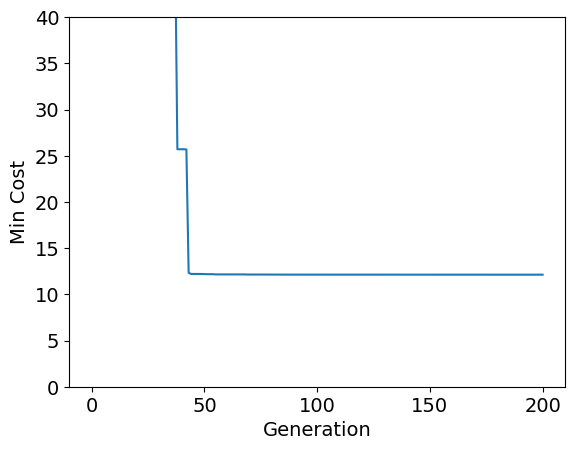

In [ ]:
# Get data from logbook
gen = logbook.select("gen")
avgs = logbook.select("avg")
stds = logbook.select("std")
mins = logbook.select("min")

# Plotting
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)
# Choosing min as mean is useless when we have such a large penalty for constaint violation
fig, ax1 = plt.subplots()
line1 = ax1.plot(gen, mins)
ax1.set_xlabel("Generation")
ax1.set_ylabel("Min Cost")
ax1.set_ylim(10, 30)